# Titanic survival prediction 
## Project objective :

The goal of this project is to analyze the titanic dataset , identify the factors that effected the passegers survival, and build a machine learning model that can predict the survival rate.

**Data base:** Titanic-Kaggle 

**Tools used**
- Python
- Pandas
- NumPy
- Matplotlib
- seaborn
- scikit-learn


In [78]:
#import necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Load the dataset 
First, load the training and testing datasets and inspect their structure.

In [79]:
import pandas as pd
train= pd.read_csv("train.csv")
test= pd.read_csv("test.csv")


print("Total Passengers:", len(train))

print("Survival Rate:",
      round(train["Survived"].mean()*100,2),"%")

print("Average Age:",
      round(train["Age"].mean(),2))

print("Number of Features:",
      train.shape[1])


Total Passengers: 891
Survival Rate: 38.38 %
Average Age: 29.7
Number of Features: 12


# Data overview 
Before cleaning the data, we inspect its structure and identify missing values.

In [80]:
train.info()
test.info()
train.describe()
test.describe()
train.isnull().sum()
test.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# Data cleaning 
The Age, Cabin, and Embarked columns contain missing values.
Age is filled with the median.
Cabin is dropped because most values are missing.
Embarked is filled with the most common value.


In [81]:
train["Age"] = train["Age"].fillna(train["Age"].median())
test["Age"] = test["Age"].fillna(test["Age"].median())
train.drop("Cabin", axis=1, inplace=True)
test.drop("Cabin", axis=1, inplace=True)
train["Embarked"] = train["Embarked"].fillna(train["Embarked"].mode()[0])
test["Fare"] = test["Fare"].fillna(test["Fare"].median())

# Does gender affect survival?
## survival by gender 
This chart compares the survival rates of male and female passengers.


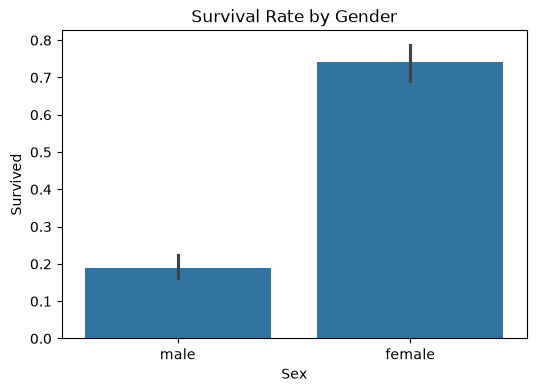

In [82]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Sex",
    y="Survived",
    data=train
)

plt.title("Survival Rate by Gender")

plt.show()

### conclusion 
Female passengers had a significantly higher survival rate than male passengers.


# Did passenger class affect survival?
## Survival by class 
This chart compares the survival rates based of passenger class.



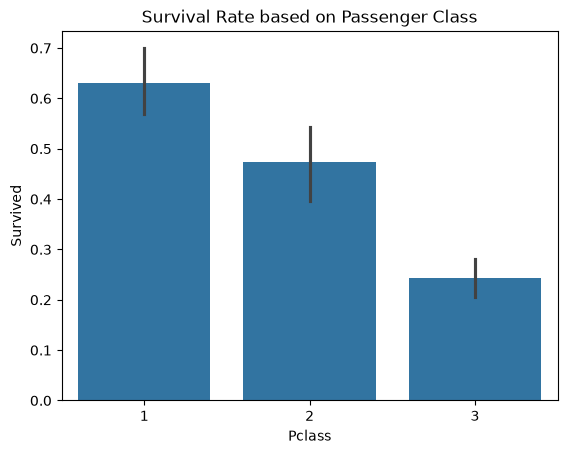

In [83]:
sns.barplot(x="Pclass", y="Survived", data=train)
plt.title("Survival Rate based on Passenger Class")
plt.show()

### conclusion 
First class passengers had higher survival chance 


# What is age distribution?
## Showing the breakdown of individuals of different ages 
This chart shows the difference of age of passengers 


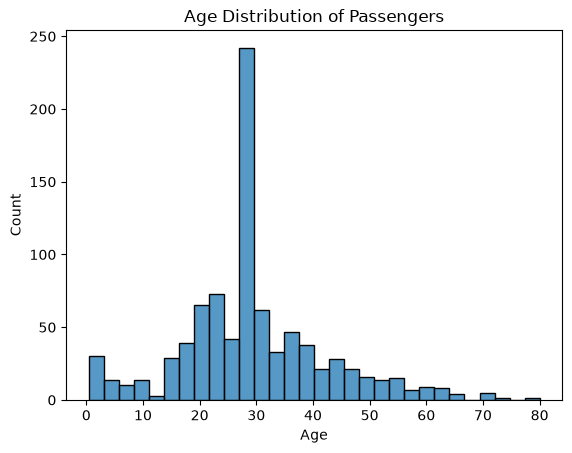

In [84]:
sns.histplot(train["Age"])
plt.title("Age Distribution of Passengers")
plt.show()

### conclusion 
The average ages of the passengers were between 25-30 




## Correlation Heatmap


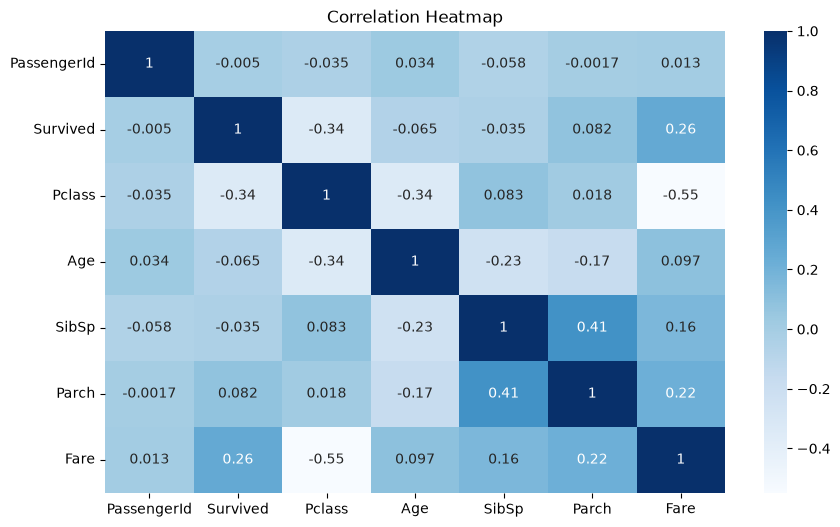

In [85]:
plt.figure(figsize=(10,6))

sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

# feature engineering 

New features were created to improve model performance.

FamilySize combines siblings/spouse and parents/children.

Title was extracted from passenger names.

In [86]:
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1
train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)
train["Title"] = train["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
test["Title"] = test["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
train["Title"] = train["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major",
     "Rev","Sir","Jonkheer","Dona"],
    "Rare"
)

test["Title"] = test["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major",
     "Rev","Sir","Jonkheer","Dona"],
    "Rare"
)
train["Title"] = train["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major",
     "Rev","Sir","Jonkheer","Dona"],
    "Rare"
)

test["Title"] = test["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major",
     "Rev","Sir","Jonkheer","Dona"],
    "Rare"
)
train["Sex"] = train["Sex"].map({
    "male":0,
    "female":1
})

test["Sex"] = test["Sex"].map({
    "male":0,
    "female":1
})
train["Embarked"] = train["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

test["Embarked"] = test["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})
title_mapping = {
    "Mr":1,
    "Miss":2,
    "Mrs":3,
    "Master":4,
    "Rare":5
}
#feature selection and model training
train["Title"] = train["Title"].map(title_mapping)
test["Title"] = test["Title"].map(title_mapping)
features = [
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",
    "FamilySize",
    "IsAlone",
    "Title"
]



<>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:6: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
/var/folders/wx/5j7pljwd7bl4vygzn8k06vmm0000gn/T/ipykernel_36951/571442670.py:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train["Title"] = train["Name"].str.extract(" ([A-Za-z]+)\.", expand=False)
/var/folders/wx/5j7pljwd7bl4vygzn8k06vmm0000gn/T/ipykernel_36951/571442670.py:6: Sy

# Model training 
A Random Forest classifier was selected because it performs well on structured datasets and requires little preprocessing.


In [87]:
X = train[features]

y = train["Survived"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)



## Model Performance

The Random Forest model achieved an accuracy of 80%, indicating that it correctly predicted survival for most passengers in the testing dataset.


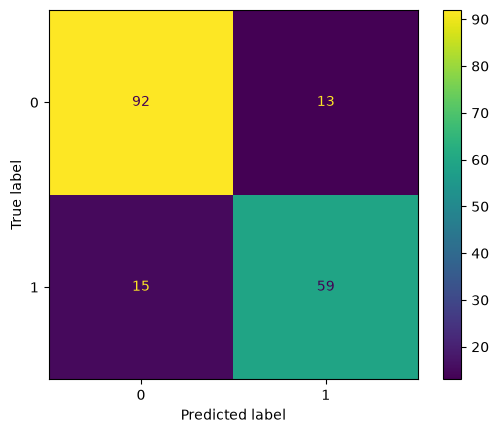

In [88]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.show()

## feature importance 
This chart shows the importance of the feature based on the survival rates 


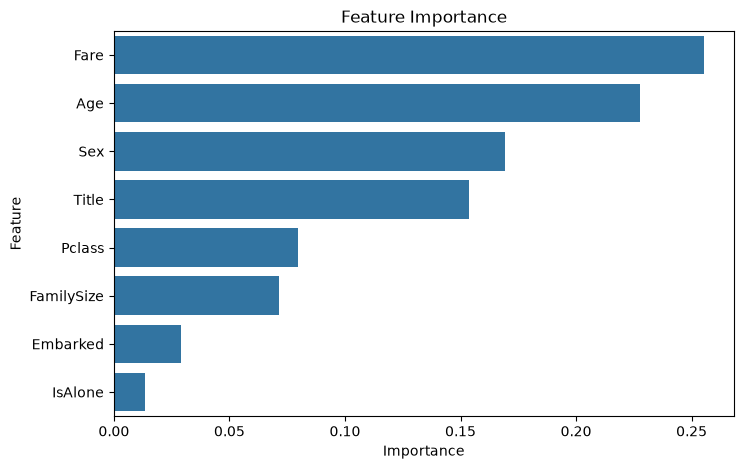

In [89]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.show()



# Final conclusion 
## key findings 
- Female passengers were much more likely to survive than male passengers.
- First-class passengers had the highest survival rate.
- Children generally had better survival rates.
- Passenger class, gender, fare, and title were the strongest predictors.
- The Random Forest model achieved approximately 80% accuracy.

This project demonstrates a complete machine learning workflow, including data cleaning, exploratory data analysis, feature engineering, model training, and evaluation.
